# Exploratory Data Analysis (EDA)
Dataset: [Telco Customer Churn](https://www.kaggle.com/datasets/blastchar/telco-customer-churn)

## Objective

This notebook performs an exploratory analysis of the Telco Customer Churn dataset to understand churn behavior, target distribution, and potential churn drivers.
The analysis is descriptive only and does not include preprocessing, feature engineering, or predictive modeling.

## Imports and Dataset Loading

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [2]:
df = pd.read_csv("../data/raw/Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Dataset Overview

In [3]:
df.shape

(7043, 21)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


- The dataset contains 7,043 rows and 21 columns, including 20 features and 1 target (Churn).
- Most variables are categorical, with only tenure, SeniorCitizen, and MonthlyCharges stored as numeric.
- TotalCharges is stored as an object, indicating a data type inconsistency for a numeric field.

In [5]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,7590-VHVEG,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


- The dataset is dominated by categorical features, with most variables having 2–4 unique categories.
- Tenure shows wide dispersion (0–72 months), while MonthlyCharges span a broad range (18.25–118.75), indicating variability in customer lifecycle and billing.
- TotalCharges appears as non-numeric with many unique string values, reinforcing a data type inconsistency for an otherwise numeric measure.

## Target Variable Distribution (Churn)

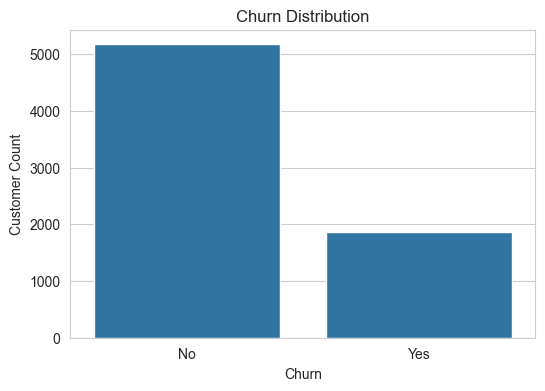

(Churn
 No     5174
 Yes    1869
 Name: count, dtype: int64,
 Churn
 No     0.735
 Yes    0.265
 Name: proportion, dtype: float64)

In [6]:
plt.figure(figsize=(6,4))
sns.countplot(x="Churn", data=df)
plt.title("Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Customer Count")
plt.show()

df["Churn"].value_counts(), df["Churn"].value_counts(normalize=True).round(3)

- The target variable is imbalanced, with 5,174 customers (73.5%) retained and 1,869 customers (26.5%) churned.
- Non-churned customers form the clear majority of the dataset.

## Tenure vs Churn

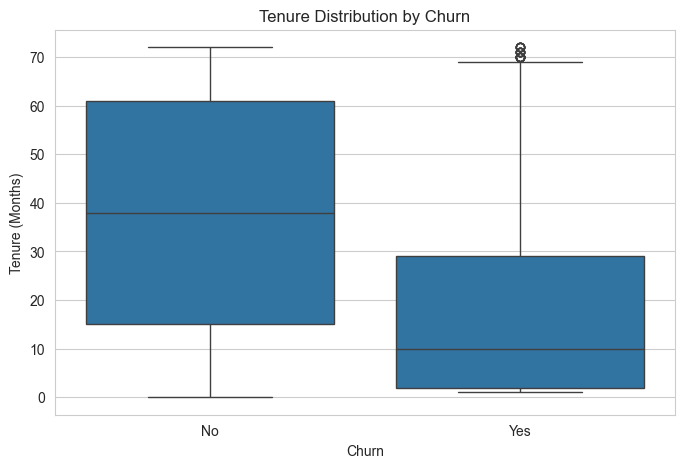

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5174.0,37.57,24.11,0.0,15.0,38.0,61.0,72.0
Yes,1869.0,17.98,19.53,1.0,2.0,10.0,29.0,72.0


In [7]:
plt.figure(figsize=(8,5))
sns.boxplot(x="Churn", y="tenure", data=df)
plt.title("Tenure Distribution by Churn")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")
plt.show()

df.groupby("Churn")["tenure"].describe().round(2)

- Customers who churn have much shorter tenure (median 10 months) compared to retained customers (median 38 months).
- The churned group is concentrated at lower tenure values, while retained customers show longer and more spread-out tenures.

## Contract vs Churn

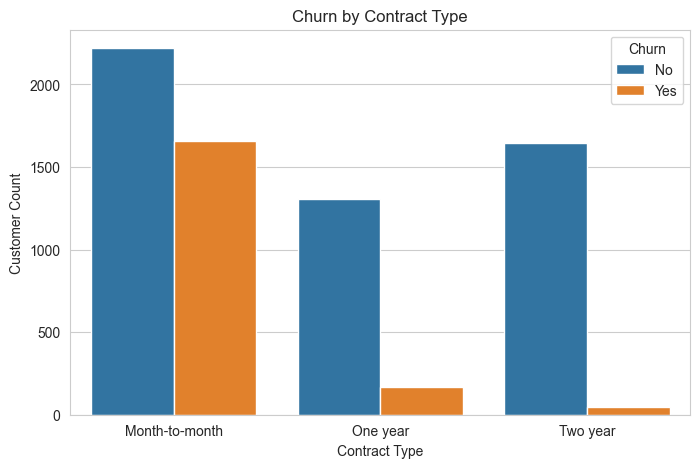

Churn,No,Yes
Contract,,
Month-to-month,0.573,0.427
One year,0.887,0.113
Two year,0.972,0.028


In [8]:
plt.figure(figsize=(8,5))
sns.countplot(x="Contract", hue="Churn", data=df)
plt.title("Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Customer Count")
plt.legend(title="Churn")
plt.show()

pd.crosstab(df["Contract"], df["Churn"], normalize="index").round(3)

- Month-to-month contracts have the highest churn rate (42.7%).
- Churn decreases substantially for one-year (11.3%) and two-year contracts (2.8%).

## Monthly Charges vs Churn

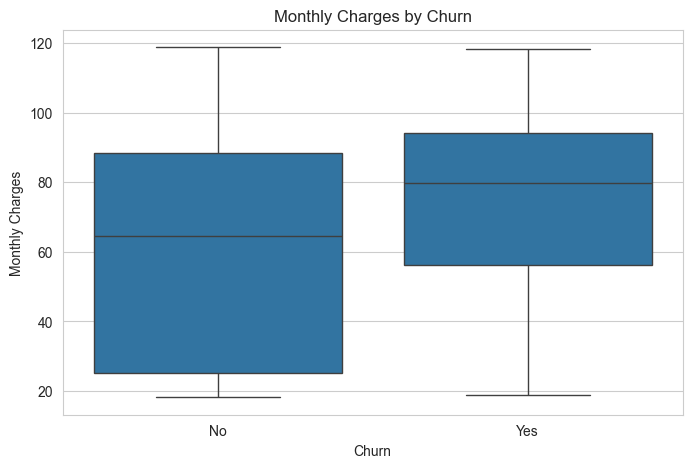

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5174.0,61.27,31.09,18.25,25.10,64.43,88.4,118.75
Yes,1869.0,74.44,24.67,18.85,56.15,79.65,94.2,118.35


In [9]:
plt.figure(figsize=(8,5))
sns.boxplot(x="Churn", y="MonthlyCharges", data=df)
plt.title("Monthly Charges by Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")
plt.show()

df.groupby("Churn")["MonthlyCharges"].describe().round(2)

- Churned customers have higher monthly charges (median 79.65) than retained customers (median 64.43).
- The charge distribution for churned customers is shifted upward across quartiles.

## Internet Service vs Churn

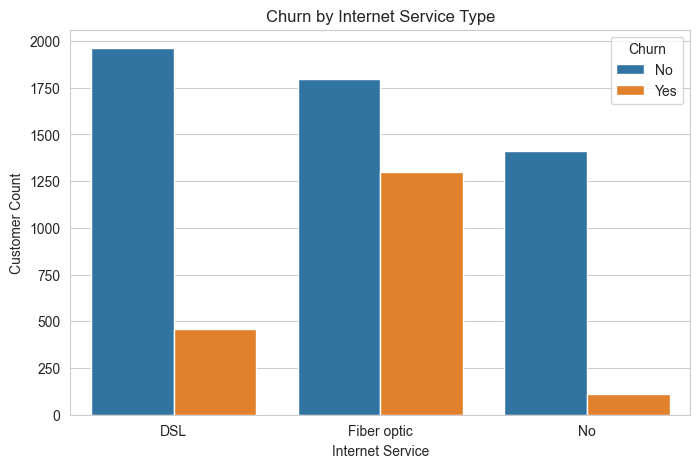

Churn,No,Yes
InternetService,,
DSL,0.810,0.190
Fiber optic,0.581,0.419
No,0.926,0.074


In [10]:
plt.figure(figsize=(8,5))
sns.countplot(x="InternetService", hue="Churn", data=df)
plt.title("Churn by Internet Service Type")
plt.xlabel("Internet Service")
plt.ylabel("Customer Count")
plt.legend(title="Churn")
plt.show()

pd.crosstab(df["InternetService"], df["Churn"], normalize="index").round(3)

- Fiber optic customers show the highest churn rate (41.9%).
- Customers with no internet service have the lowest churn rate (7.4%), while DSL users fall in between (19.0%).

## Tech Support vs Churn

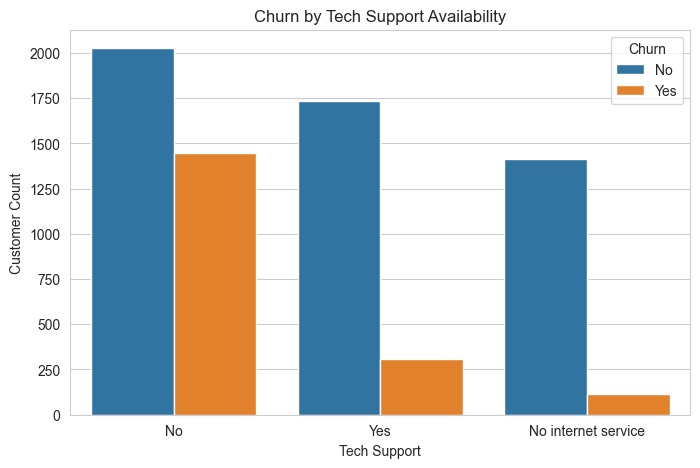

Churn,No,Yes
TechSupport,,
No,0.584,0.416
No internet service,0.926,0.074
Yes,0.848,0.152


In [11]:
plt.figure(figsize=(8,5))
sns.countplot(x="TechSupport", hue="Churn", data=df)
plt.title("Churn by Tech Support Availability")
plt.xlabel("Tech Support")
plt.ylabel("Customer Count")
plt.legend(title="Churn")
plt.show()

pd.crosstab(df["TechSupport"], df["Churn"], normalize="index").round(3)

- Customers without tech support have a high churn rate (41.6%).
- Churn is lower for customers with tech support (15.2%) and lowest for those with no internet service (7.4%).

## Payment Method vs Churn

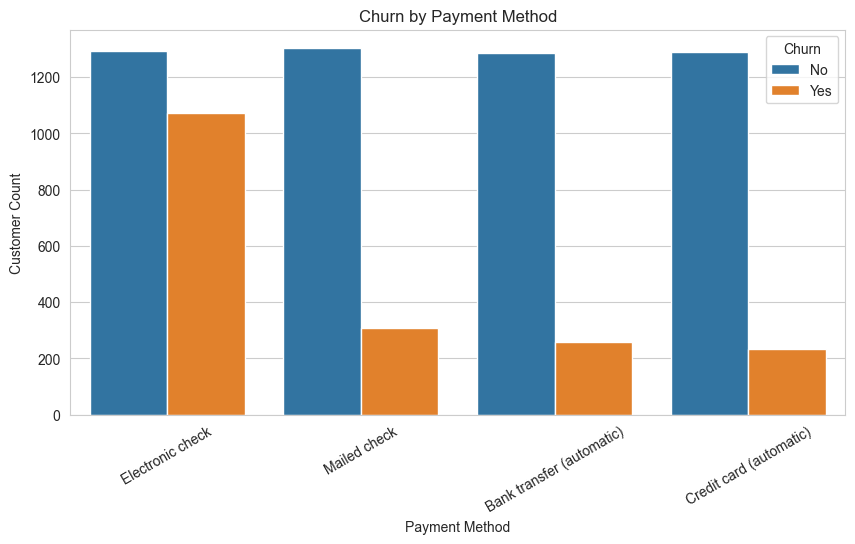

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),0.833,0.167
Credit card (automatic),0.848,0.152
Electronic check,0.547,0.453
Mailed check,0.809,0.191


In [12]:
plt.figure(figsize=(10,5))
sns.countplot(x="PaymentMethod", hue="Churn", data=df)
plt.title("Churn by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Customer Count")
plt.legend(title="Churn")
plt.xticks(rotation=30)
plt.show()

pd.crosstab(df["PaymentMethod"], df["Churn"], normalize="index").round(3)

- Electronic check users exhibit the highest churn rate (45.3%).
- Customers using automatic payment methods (bank transfer or credit card) show substantially lower churn rates (15–17%).

## Churn Rate by Key Categorical Features

In [13]:
def churn_rate_by_feature(df, feature):
    return (
        df.groupby(feature)["Churn"]
          .value_counts(normalize=True)
          .rename("ChurnRate")
          .reset_index()
          .query("Churn == 'Yes'")
          .drop(columns="Churn")
          .sort_values("ChurnRate", ascending=False)
    )

tables = []

for col in ["Contract", "InternetService", "TechSupport", "PaymentMethod"]:
    t = churn_rate_by_feature(df, col)
    t.insert(0, "Feature", col)
    tables.append(t)

churn_rate_table = pd.concat(tables, ignore_index=True)
churn_rate_table

,Feature,Contract,ChurnRate,InternetService,TechSupport,PaymentMethod
0,Contract,Month-to-month,0.427097,NaN,NaN,NaN
1,Contract,One year,0.112695,NaN,NaN,NaN
2,Contract,Two year,0.028319,NaN,NaN,NaN
3,InternetService,NaN,0.418928,Fiber optic,NaN,NaN
4,InternetService,NaN,0.189591,DSL,NaN,NaN
5,InternetService,NaN,0.074050,No,NaN,NaN
6,TechSupport,NaN,0.416355,NaN,No,NaN
7,TechSupport,NaN,0.151663,NaN,Yes,NaN
8,TechSupport,NaN,0.074050,NaN,No internet service,NaN
9,PaymentMethod,NaN,0.452854,NaN,NaN,Electronic check


- Month-to-month contracts show the highest churn rate (42.7%), while two-year contracts have the lowest (2.8%).
- Fiber optic users exhibit elevated churn (41.9%) compared to DSL (19.0%) and no internet service (7.4%).
- Customers without tech support (41.6%) and those using electronic checks (45.3%) have the highest churn rates within their respective categories.

## Numeric Feature Summary by Churn

In [14]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

numeric_summary = (
    df.groupby("Churn")[["tenure", "MonthlyCharges", "TotalCharges"]]
      .agg(["mean", "median", "std"])
)

numeric_summary

tenure                   MonthlyCharges                     \
            mean median        std           mean  median        std   
Churn                                                                  
No     37.569965   38.0  24.113777      61.265124  64.425  31.092648   
Yes    17.979133   10.0  19.531123      74.441332  79.650  24.666053   

      TotalCharges                        
              mean   median          std  
Churn                                     
No     2555.344141  1683.60  2329.456984  
Yes    1531.796094   703.55  1890.822994

- Churned customers have shorter tenure (median 10 vs 38 months) and lower total charges (median 703.55 vs 1683.60).
- Monthly charges are higher for churned customers (median 79.65) compared to retained customers (64.43).

## EDA Summary and Implications

The Telco Customer Churn dataset consists of **7,043 customers and 21 variables**, with a strong dominance of **categorical features** and only a few numeric attributes (tenure, SeniorCitizen, MonthlyCharges). A notable data quality issue is that **TotalCharges is stored as a non-numeric object**, requiring type correction before quantitative analysis or modeling.

The **target variable (Churn) is moderately imbalanced**, with **26.5% churned customers**, indicating that evaluation metrics beyond raw accuracy will be important in downstream modeling.

Across all analyses, **customer tenure emerges as the most critical differentiating factor**: churned customers have a **substantially shorter tenure** (median 10 months) compared to retained customers (median 38 months). This pattern is consistently reinforced by contract type, where **month-to-month contracts exhibit very high churn (42.7%)**, while long-term contracts (especially two-year contracts at 2.8%) are strongly associated with retention.

Pricing and service-related features further sharpen this pattern. **Churned customers pay higher monthly charges**, yet accumulate **lower total charges**, reflecting early exit despite higher ongoing costs. Elevated churn is concentrated among **fiber optic users**, customers **without tech support**, and those using **electronic check payments**, all of which show churn rates exceeding 40%.

### Direct Implications
- **Modeling:** Tenure, contract type, monthly charges, and service/payment attributes are likely to be high-importance predictors. The observed class imbalance suggests the need for appropriate evaluation metrics and possibly imbalance-aware techniques.
- **Business:** Churn is primarily an **early-lifecycle problem**, amplified by **short-term contracts, higher monthly costs, and lack of support services**. Retention strategies should prioritize early-tenure customers, incentivize longer contracts, promote tech support adoption, and encourage automatic payment methods.